# Milestone 2: Exploratory Analysis + Feature Engineering

This notebook covers:
- Growth over time
- Genre and rating distributions by content type
- Country-level content contribution
- Feature engineering for duration categories and content origin


In [23]:
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.max_columns = 50
sns.set_theme(style="whitegrid")

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / 'data' / 'processed' / 'netflix_titles_cleaned.csv').exists():
            return parent
    return start

ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / 'data' / 'processed' / 'netflix_titles_cleaned.csv'


In [24]:
df = pd.read_csv(DATA_PATH)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows|TV Dramas|TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows|International TV Shows|TV Actio...,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,Docuseries|Reality TV,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows|Romantic TV Shows|TV Co...,In a city of coaching centers known to train I...


## Growth Over Time


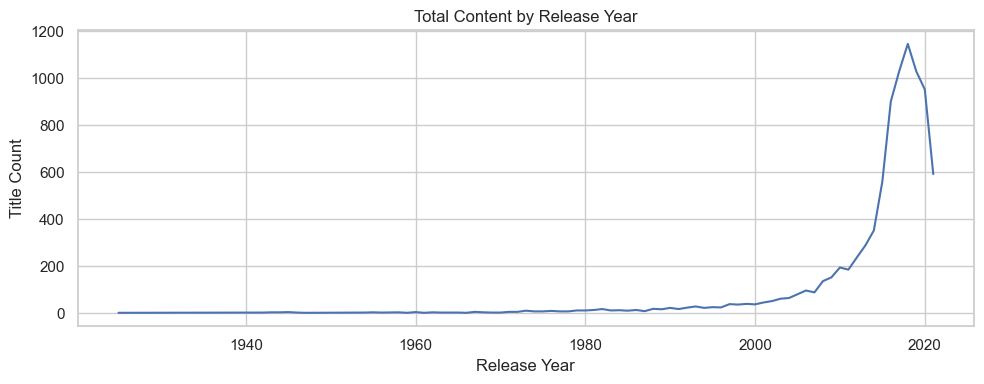

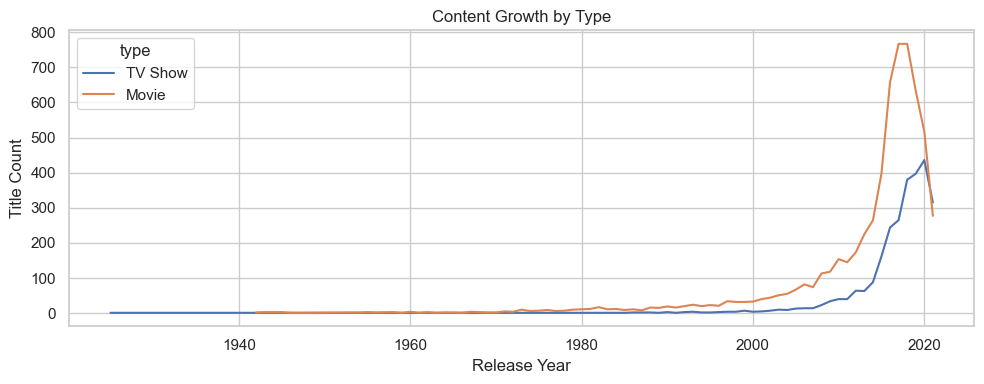

In [25]:
growth = df.groupby("release_year").size().reset_index(name="count")
plt.figure(figsize=(10, 4))
sns.lineplot(data=growth, x="release_year", y="count")
plt.title("Total Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Title Count")
plt.tight_layout()
plt.show()

growth_type = df.groupby(["release_year", "type"]).size().reset_index(name="count")
plt.figure(figsize=(10, 4))
sns.lineplot(data=growth_type, x="release_year", y="count", hue="type")
plt.title("Content Growth by Type")
plt.xlabel("Release Year")
plt.ylabel("Title Count")
plt.tight_layout()
plt.show()


## Genre Distribution (Movies vs TV Shows)


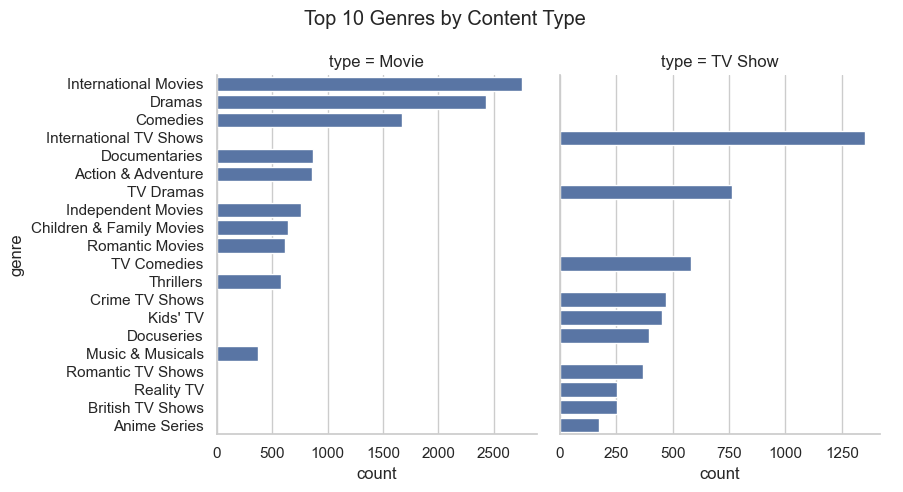

In [26]:
genres = df.assign(genre=df["listed_in"].str.split("|")).explode("genre")
genre_counts = genres.groupby(["type", "genre"]).size().reset_index(name="count")
top_genres = (
    genre_counts.sort_values("count", ascending=False)
    .groupby("type")
    .head(10)
)

g = sns.catplot(
    data=top_genres,
    kind="bar",
    x="count",
    y="genre",
    col="type",
    height=5,
    aspect=0.9,
    sharex=False,
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Top 10 Genres by Content Type")
plt.show()


## Rating Distribution (Movies vs TV Shows)


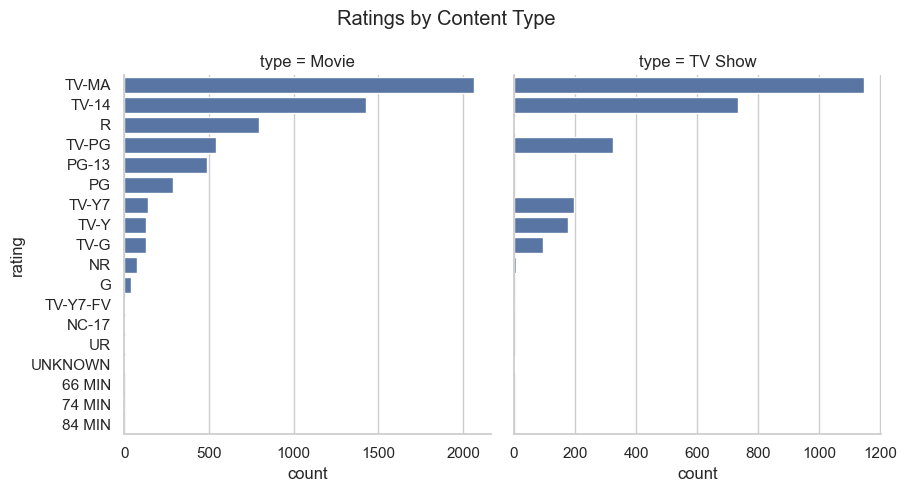

In [27]:
rating_counts = df.groupby(["type", "rating"]).size().reset_index(name="count")
rating_counts = rating_counts.sort_values(["type", "count"], ascending=[True, False])

g = sns.catplot(
    data=rating_counts,
    kind="bar",
    x="count",
    y="rating",
    col="type",
    height=5,
    aspect=0.9,
    sharex=False,
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Ratings by Content Type")
plt.show()


## Country-Level Content Contribution


C:\Users\Harshith\AppData\Local\Temp\ipykernel_11320\2289161420.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x="count", y="country", palette="viridis")


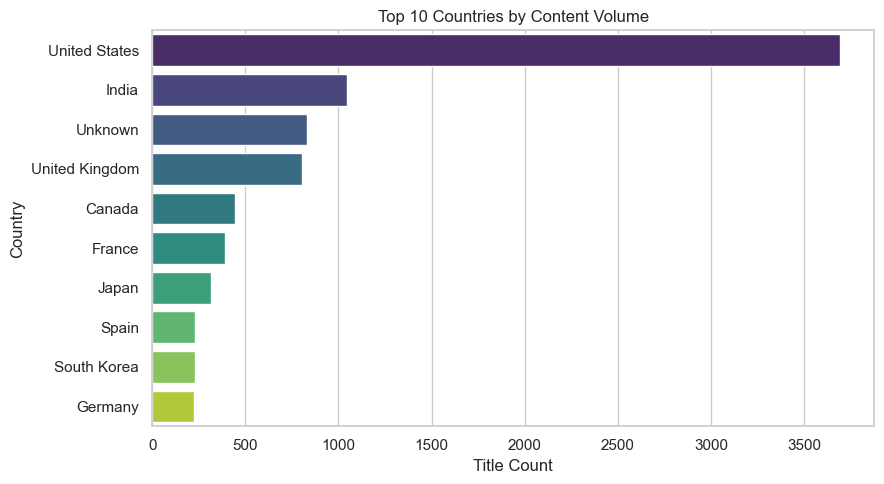

In [28]:
countries = df.assign(country=df["country"].str.split("|")).explode("country")
country_counts = countries.groupby("country").size().reset_index(name="count")
top_countries = country_counts.sort_values("count", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=top_countries, x="count", y="country", palette="viridis")
plt.title("Top 10 Countries by Content Volume")
plt.xlabel("Title Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


## Feature Engineering


In [29]:
sys.path.append(str((ROOT / 'src').resolve()))
from feature_engineering import add_feature_columns

featured = add_feature_columns(df)
featured[['duration', 'duration_value', 'duration_unit', 'length_category', 'content_origin']].head()


,duration,duration_value,duration_unit,length_category,content_origin
0,90 min,90.0,min,Medium,Licensed
1,2 Seasons,2.0,seasons,Medium,Original
2,1 Season,1.0,seasons,Short,Original
3,1 Season,1.0,seasons,Short,Original
4,2 Seasons,2.0,seasons,Medium,Original


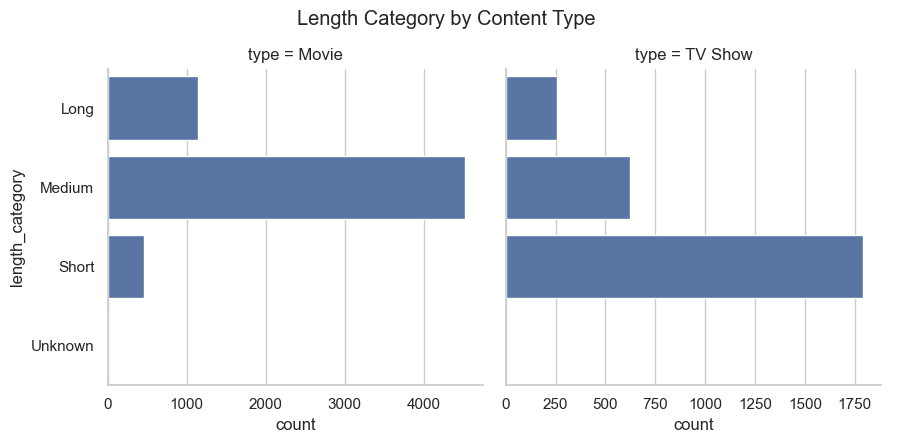

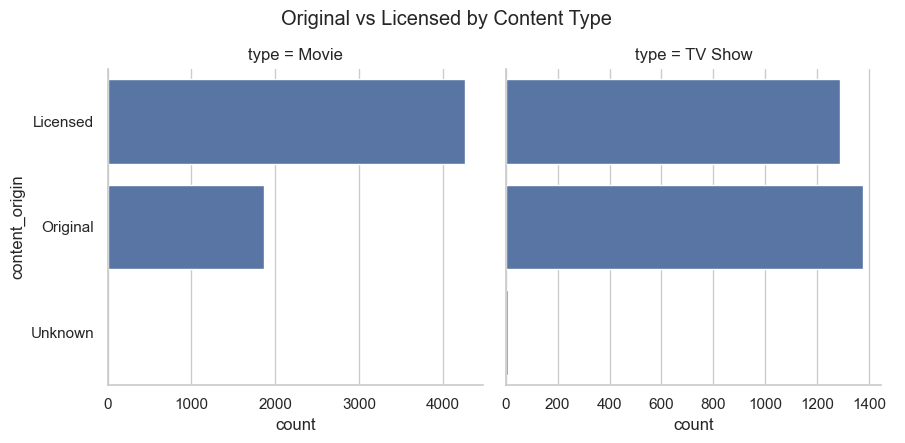

In [30]:
length_counts = featured.groupby(["type", "length_category"]).size().reset_index(name="count")
g = sns.catplot(
    data=length_counts,
    kind="bar",
    x="count",
    y="length_category",
    col="type",
    height=4.5,
    aspect=1.0,
    sharex=False,
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Length Category by Content Type")
plt.show()

origin_counts = featured.groupby(["type", "content_origin"]).size().reset_index(name="count")
g = sns.catplot(
    data=origin_counts,
    kind="bar",
    x="count",
    y="content_origin",
    col="type",
    height=4.5,
    aspect=1.0,
    sharex=False,
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Original vs Licensed by Content Type")
plt.show()


In [31]:
FEATURED_PATH = ROOT / 'data' / 'processed' / 'netflix_titles_featured.csv'
FEATURED_PATH.parent.mkdir(parents=True, exist_ok=True)
featured.to_csv(FEATURED_PATH, index=False)
FEATURED_PATH


WindowsPath('c:/Users/Harshith/Infosys Internship/data/processed/netflix_titles_featured.csv')